In [9]:
!pip install -q yt-dlp opencv-python-headless matplotlib scikit-learn tensorflow

In [10]:
import os
RAR_FILE = "UCF11_updated_mpg.rar"
DATA_DIR = "UCF11_updated_mpg"
# ── Download using wget  ───────────────
if not os.path.exists(RAR_FILE):
    print("Downloading UCF11 dataset (~1.6 GB) ...")
    !wget --no-check-certificate -q --show-progress \
        "https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar" \
        -O "{RAR_FILE}"
    print("Download complete.")
else:
    print("Archive already present.")

# ── Extract ───────────────────────────────────────────────────────────
if not os.path.exists(DATA_DIR):
    print("Extracting ...")
    !apt-get install -y -q unrar
    !unrar x -y "{RAR_FILE}" > /dev/null
    print("Extraction complete.")
else:
    print("Already extracted.")

UCF11_updated_mpg.r 100%[===================>] 996.69M  47.6MB/s    in 21s     
Download complete.
Extracting ...
Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Extraction complete.


In [11]:
#verfying the class folders are available or not
import os
for entry in os.listdir("."):
    if os.path.isdir(entry) and "UCF" in entry:
        DATA_DIR = entry
        break

classes_available = sorted(os.listdir(DATA_DIR))
print(f"Dataset root : {DATA_DIR}")
print(f"Classes found ({len(classes_available)}):")
for c in classes_available:
    print(" ", c)

Dataset root : UCF11_updated_mpg
Classes found (11):
  basketball
  biking
  diving
  golf_swing
  horse_riding
  soccer_juggling
  swing
  tennis_swing
  trampoline_jumping
  volleyball_spiking
  walking


In [13]:
import os
import glob   # ← add this

# Class names
CHOSEN_CLASSES = ["basketball", "biking", "tennis_swing"]
CLASS_TO_IDX   = {cls: i for i, cls in enumerate(CHOSEN_CLASSES)}
IDX_TO_CLASS   = {i: cls for cls, i in CLASS_TO_IDX.items()}

print("Selected classes:", CHOSEN_CLASSES)
print("Label mapping   :", CLASS_TO_IDX)

video_paths, labels = [], []

for cls in CHOSEN_CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    all_files = glob.glob(os.path.join(cls_dir, "**", "*"), recursive=True)

    vids = [
        f for f in all_files
        if os.path.isfile(f) and os.path.splitext(f)[1].lower() == ".mpg"
    ]

    print(f"  done {cls}: {len(vids)} videos")
    video_paths.extend(vids)
    labels.extend([CLASS_TO_IDX[cls]] * len(vids))

print(f"\nTotal videos: {len(video_paths)}")


# corrected class names
CHOSEN_CLASSES = ["golf_swing", "tennis_swing", "diving"]
CLASS_TO_IDX   = {cls: i for i, cls in enumerate(CHOSEN_CLASSES)}
IDX_TO_CLASS   = {i: cls for cls, i in CLASS_TO_IDX.items()}

print("Selected classes:", CHOSEN_CLASSES)
print("Label mapping   :", CLASS_TO_IDX)

video_paths, labels = [], []

for cls in CHOSEN_CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    all_files = glob.glob(os.path.join(cls_dir, "**", "*"), recursive=True)

    # Only .mpg files (ignore .xgtf annotation files)
    vids = [
        f for f in all_files
        if os.path.isfile(f) and os.path.splitext(f)[1].lower() == ".mpg"
    ]

    print(f"  done {cls}: {len(vids)} videos")
    video_paths.extend(vids)
    labels.extend([CLASS_TO_IDX[cls]] * len(vids))

print(f"\nTotal videos: {len(video_paths)}")

Selected classes: ['basketball', 'biking', 'tennis_swing']
Label mapping   : {'basketball': 0, 'biking': 1, 'tennis_swing': 2}
  done basketball: 141 videos
  done biking: 145 videos
  done tennis_swing: 167 videos

Total videos: 453
Selected classes: ['golf_swing', 'tennis_swing', 'diving']
Label mapping   : {'golf_swing': 0, 'tennis_swing': 1, 'diving': 2}
  done golf_swing: 142 videos
  done tennis_swing: 167 videos
  done diving: 156 videos

Total videos: 465


Preprocessing videos — please wait ...
X shape : (465, 16, 224, 224, 3)
y shape : (465,)
Class distribution: {'golf_swing': 142, 'tennis_swing': 167, 'diving': 156}


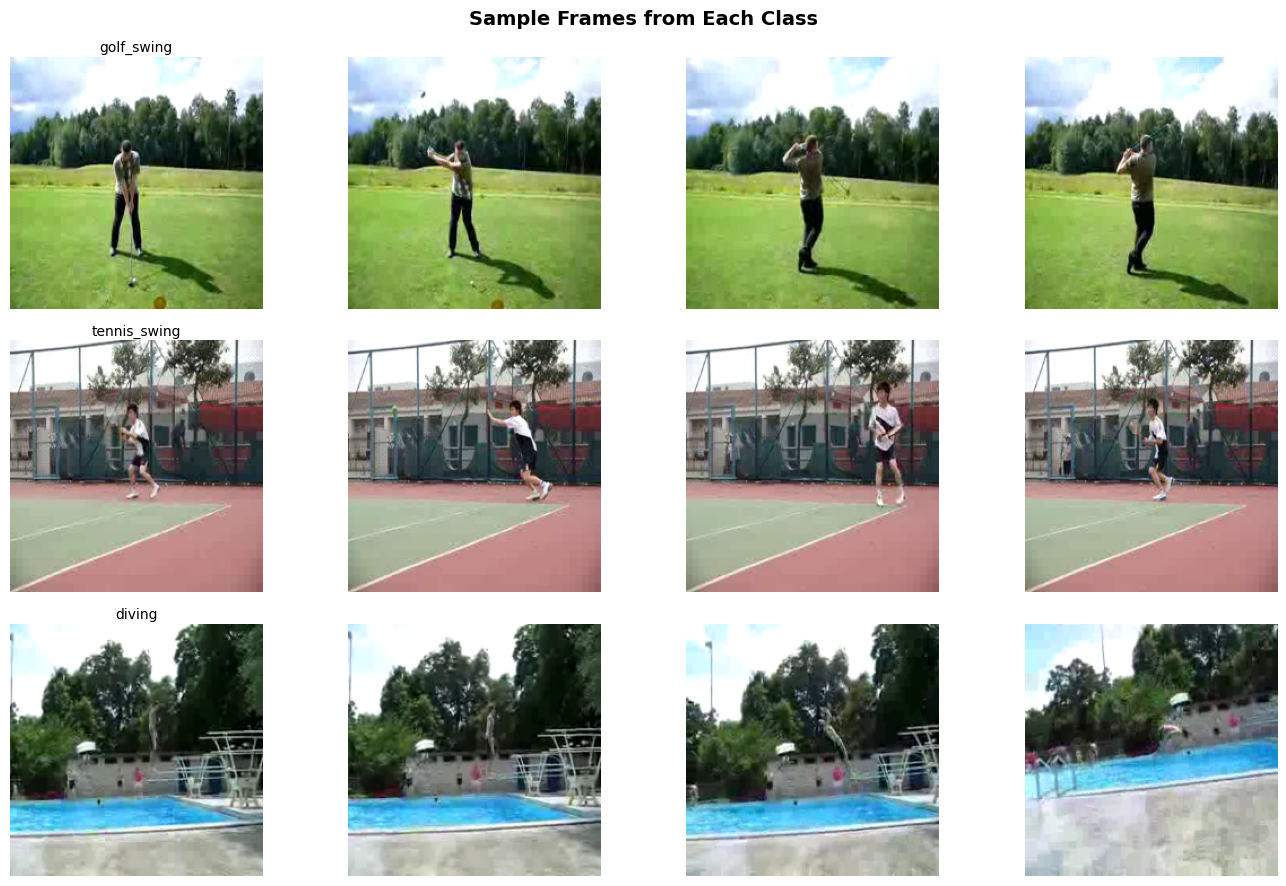

In [14]:
#visual sanity checking
import matplotlib.pyplot as plt
import os
import glob
import cv2
import numpy as np   # ← add this

IMG_SIZE     = 224
SEQUENCE_LEN = 16

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0


print("Preprocessing videos — please wait ...")
X, y = [], []

for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class distribution: { {cls: int(np.sum(y==i)) for cls, i in CLASS_TO_IDX.items()} }")
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Sample Frames from Each Class", fontsize=14, fontweight="bold")

for row, cls_idx in enumerate(range(len(CHOSEN_CLASSES))):
    class_indices = np.where(y == cls_idx)[0]

    # pick a different video of the same class
    if len(class_indices) > 1:
        sample_vid_idx = class_indices[1]
    else:
        sample_vid_idx = class_indices[0]

    frames = X[sample_vid_idx]  # 16 frames
    for col, frame_idx in enumerate([0, 4, 8, 12]):
        axes[row, col].imshow(frames[frame_idx])
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(IDX_TO_CLASS[cls_idx], fontsize=10, pad=4)

plt.tight_layout()
plt.show()

In [15]:
import cv2
import numpy as np

IMG_SIZE       = 224      # MobileNetV2 expects 224×224
SEQUENCE_LEN   = 16       # frames sampled per video
# ──────────────────────────────────────────────────────────────────────

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    """Uniformly sample n_frames from a video and return as numpy array."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0   # normalise to [0,1]


print("Preprocessing videos — please wait ...")
X, y = [], []

for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)   # shape: (N, 16, 224, 224, 3)
y = np.array(y)   # shape: (N,)

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class distribution: { {cls: int(np.sum(y==i)) for cls,i in CLASS_TO_IDX.items()} }")

Preprocessing videos — please wait ...

X shape : (465, 16, 224, 224, 3)
y shape : (465,)
Class distribution: {'golf_swing': 142, 'tennis_swing': 167, 'diving': 156}


In [16]:

from sklearn.model_selection import train_test_split
import tensorflow as tf

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

NUM_CLASSES = len(CHOSEN_CLASSES)
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing  samples  : {X_test.shape[0]}")
print(f"Input tensor shape: {X_train.shape}  →  (samples, frames, H, W, C)")

Training samples  : 372
Testing  samples  : 93
Input tensor shape: (372, 16, 224, 224, 3)  →  (samples, frames, H, W, C)


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_lstm_model(sequence_len, img_size, num_classes):
    # ── CNN Backbone (MobileNetV2, ImageNet weights, frozen) ──────────
    base_cnn = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base_cnn.trainable = False   # freeze for initial training

    # ── Full Model ────────────────────────────────────────────────────
    inp = layers.Input(shape=(sequence_len, img_size, img_size, 3))

    # Apply MobileNetV2 to every frame
    x = layers.TimeDistributed(base_cnn)(inp)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)  # (batch, seq, 1280)

    # Temporal modelling
    x = layers.LSTM(128, return_sequences=False)(x)
    x = layers.Dropout(0.4)(x)

    # Classifier head
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inp, out, name="CNN_LSTM_ActionRecognizer")
    return model, base_cnn


model, base_cnn = build_cnn_lstm_model(SEQUENCE_LEN, IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CNN_LSTM_ActionRecognizer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,843 (11.40 MB)

 Trainable params: 729,859 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Step 1: Free up GPU memory before training ────────────────────────
tf.keras.backend.clear_session()
import gc; gc.collect()

# ── Step 2: Reduce input size to fit in Colab GPU memory ──────────────
IMG_SIZE     = 112   # reduced from 224 → 4x less memory per frame
SEQUENCE_LEN = 8     # reduced from 16  → 2x less memory per sample

# ── Step 3: Re-preprocess with smaller sizes ──────────────────────────
print("Re-preprocessing with reduced dimensions ...")

def extract_frames(video_path, n_frames=SEQUENCE_LEN, img_size=IMG_SIZE):
    import cv2, numpy as np
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        frame = cv2.resize(frame, (img_size, img_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0

import numpy as np
X, y = [], []
for path, label in zip(video_paths, labels):
    frames = extract_frames(path)
    if frames is not None and len(frames) == SEQUENCE_LEN:
        X.append(frames)
        y.append(label)

X = np.array(X)
y = np.array(y)
print(f"✅ X shape: {X.shape}  y shape: {y.shape}")

# ── Step 4: Re-split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
NUM_CLASSES  = len(CHOSEN_CLASSES)
y_train_cat  = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat   = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

# ── Step 5: Rebuild lighter model for 112x112 input ───────────────────
from tensorflow.keras import layers, models

def build_model(seq_len, img_size, num_classes):
    # MobileNetV2 still works at 112x112 (minimum is 96x96)
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    inp = layers.Input(shape=(seq_len, img_size, img_size, 3))
    x   = layers.TimeDistributed(base)(inp)
    x   = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    x   = layers.LSTM(64, return_sequences=False)(x)   # 64 instead of 128
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(64, activation="relu")(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out), base

model, base_cnn = build_model(SEQUENCE_LEN, IMG_SIZE, NUM_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("✅ Model rebuilt")

# ── Step 6: Train with mixed precision + smaller batch ────────────────
tf.keras.mixed_precision.set_global_policy("mixed_float16")  # halves VRAM usage

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.h5", monitor="val_accuracy",
                    save_best_only=True, verbose=1)
]

print("=" * 55)
print(" Phase 1: Training head only (backbone frozen)")
print("=" * 55)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=25,
    batch_size=2,        # reduced from 4 → safest for Colab
    callbacks=callbacks
)


Re-preprocessing with reduced dimensions ...
✅ X shape: (465, 8, 112, 112, 3)  y shape: (465,)
Train: 372  Test: 93


/tmp/ipykernel_6824/2514914039.py:62: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


✅ Model rebuilt
 Phase 1: Training head only (backbone frozen)
Epoch 1/25
185/186 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5876 - loss: 0.8629
Epoch 1: val_accuracy improved from None to 0.94624, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 51s 105ms/step - accuracy: 0.7688 - loss: 0.5720 - val_accuracy: 0.9462 - val_loss: 0.1483 - learning_rate: 0.0010
Epoch 2/25
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9704 - loss: 0.1493
Epoch 2: val_accuracy improved from 0.94624 to 1.00000, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9677 - loss: 0.1417 - val_accuracy: 1.0000 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 3/25
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9860 - loss: 0.0640
Epoch 3: val_accuracy did not improve from 1.00000
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.9866 - loss: 0.0538 - val_accuracy: 1.0000 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 4/25
185/186 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9903 - loss: 0.0359
Epoch 4: val_accuracy did not improve from 1.00000
186/186 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9892 - loss: 0.0375 - val_accuracy: 1.0000 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 5/25
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9943 - loss: 0.0337
Epoch 5: val_accuracy did not improve from 1.00000
186/186 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9866 - loss: 0.0451 - val_accuracy: 0.9892 - val_loss:

In [19]:
# step 2: Fine-tune( unfreeze top layers of MobileNetV2 )
print("=" * 55)
print(" Phase 2: Fine-tuning top layers of backbone")
print("=" * 55)

base_cnn.trainable = True

# Unfreeze only the last 30 layers
for layer in base_cnn.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=15,
    batch_size=4,
    callbacks=callbacks
)

 Phase 2: Fine-tuning top layers of backbone
Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6674 - loss: 0.8832
Epoch 1: val_accuracy did not improve from 1.00000
93/93 ━━━━━━━━━━━━━━━━━━━━ 57s 185ms/step - accuracy: 0.6855 - loss: 0.8523 - val_accuracy: 1.0000 - val_loss: 0.0206 - learning_rate: 1.0000e-05
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7705 - loss: 0.6018
Epoch 2: val_accuracy did not improve from 1.00000
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.7715 - loss: 0.5890 - val_accuracy: 1.0000 - val_loss: 0.0349 - learning_rate: 1.0000e-05
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8623 - loss: 0.3376
Epoch 3: val_accuracy did not improve from 1.00000
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8683 - loss: 0.3142 - val_accuracy: 1.0000 - val_loss: 0.0425 - learning_rate: 1.0000e-05
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8713 - loss: 0.4607
Epoch 4: ReduceLROnPlateau r

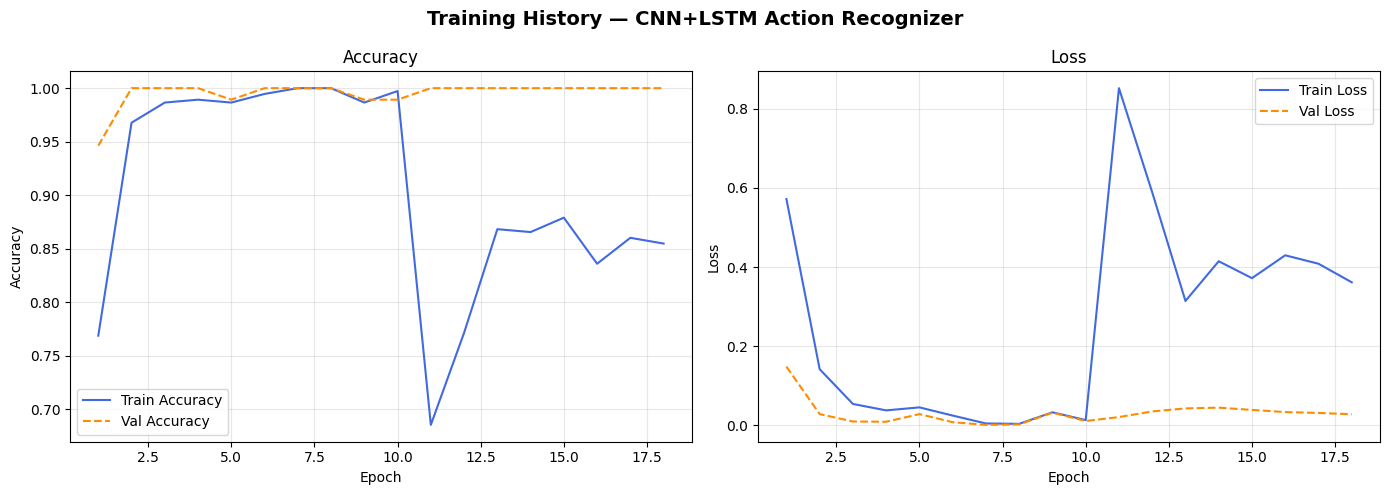

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Combine both training phases
def merge_hist(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc     = merge_hist(history, history_ft, "accuracy")
val_acc = merge_hist(history, history_ft, "val_accuracy")
loss    = merge_hist(history, history_ft, "loss")
val_los = merge_hist(history, history_ft, "val_loss")
ep      = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History — CNN+LSTM Action Recognizer", fontsize=14, fontweight="bold")

ax1.plot(ep, acc,     label="Train Accuracy",   color="royalblue")
ax1.plot(ep, val_acc, label="Val Accuracy",     color="darkorange", linestyle="--")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss,    label="Train Loss",       color="royalblue")
ax2.plot(ep, val_los, label="Val Loss",         color="darkorange", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Test Accuracy : 100.00%
Test Loss     : 0.0206

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step
              precision    recall  f1-score   support

  golf_swing       1.00      1.00      1.00        29
tennis_swing       1.00      1.00      1.00        33
      diving       1.00      1.00      1.00        31

    accuracy                           1.00        93
   macro avg       1.00      1.00      1.00        93
weighted avg       1.00      1.00      1.00        93



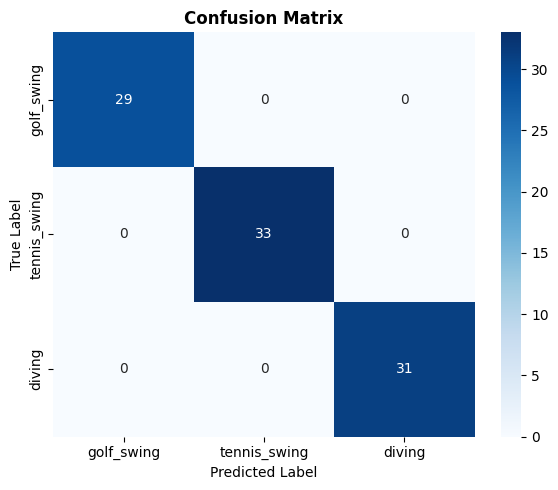

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n{'='*40}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print(f"{'='*40}\n")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=CHOSEN_CLASSES))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CHOSEN_CLASSES, yticklabels=CHOSEN_CLASSES)
plt.title("Confusion Matrix", fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

In [22]:
student_name = "Jawan"

save_path = f"{student_name}_ucf11_model.h5"

# Saving the full model
model.save(save_path)
print(f"✅ Model saved as: {save_path}")



✅ Model saved as: Jawan_ucf11_model.h5


In [23]:
import json
from google.colab import files

student_name = "Jawan"
#metadata file
meta = {
    "student"      : student_name,
    "classes"      : CHOSEN_CLASSES,
    "label_map"    : CLASS_TO_IDX,
    "sequence_len" : SEQUENCE_LEN,
    "img_size"     : IMG_SIZE,
    "test_accuracy": round(float(test_acc), 4)
}

meta_path = f"{student_name}_metadata.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"✅ Metadata created: {meta_path}")
print(json.dumps(meta, indent=2))

files.download(save_path)
files.download(meta_path)

✅ Metadata created: Jawan_metadata.json
{
  "student": "Jawan",
  "classes": [
    "golf_swing",
    "tennis_swing",
    "diving"
  ],
  "label_map": {
    "golf_swing": 0,
    "tennis_swing": 1,
    "diving": 2
  },
  "sequence_len": 8,
  "img_size": 112,
  "test_accuracy": 1.0
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import files
files.download(save_path)
files.download(f"{student_name}_metadata.json")
# Install yt-dlp
!pip install -q yt-dlp
!yt-dlp --version

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2026.03.17


In [25]:
import os
print(os.listdir())

['.config', 'Jawan_metadata.json', 'UCF11.rar', 'best_model.h5', 'UCF11_updated_mpg', 'UCF11_updated_mpg.rar', 'Jawan_ucf11_model.h5', 'sample_data']


In [29]:
!yt-dlp -f mp4 -o "golf.mp4" "https://www.youtube.com/shorts/i1flY8dg5Kw"
!yt-dlp -f mp4 -o "tennis.mp4" "https://www.youtube.com/watch?v=QAcBgVZheDo"
!yt-dlp -f mp4 -o "diving.mp4" "https://www.youtube.com/shorts/gfU717Rw8dY"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://www.youtube.com/shorts/i1flY8dg5Kw
[youtube] i1flY8dg5Kw: Downloading webpage
[youtube] i1flY8dg5Kw: Downloading android vr player API JSON
[info] i1flY8dg5Kw: Downloading 1 format(s): 18
[download] Destination: golf.mp4
[download] 100% of  400.35KiB in 00:00:00 at 4.19MiB/s
         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracti

✅ Model loaded

Video: golf.mp4
Expected: golf_swing
Predicted: golf_swing ✅
Confidence: {'golf_swing': '97.5%', 'tennis_swing': '1.5%', 'diving': '1.0%'}

Video: tennis.mp4
Expected: tennis_swing
Predicted: tennis_swing ✅
Confidence: {'golf_swing': '31.3%', 'tennis_swing': '66.7%', 'diving': '2.0%'}

Video: diving.mp4
Expected: diving
Predicted: diving ✅
Confidence: {'golf_swing': '0.8%', 'tennis_swing': '0.2%', 'diving': '99.1%'}


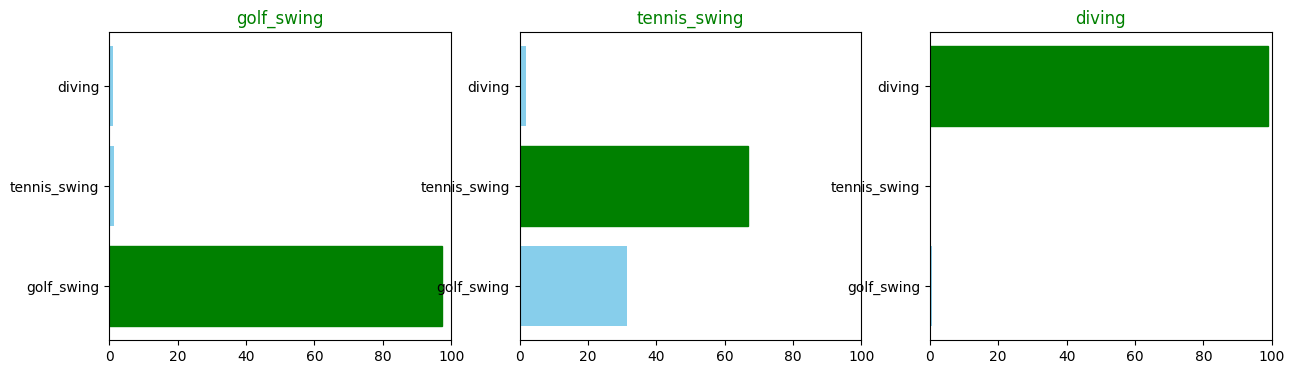

In [30]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# SETTINGS
SEQUENCE_LEN = 8
IMG_SIZE = 112
CHOSEN_CLASSES = ["golf_swing", "tennis_swing", "diving"]

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CHOSEN_CLASSES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CHOSEN_CLASSES)

# FRAME EXTRACTION
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total < 1:
        return None

    indices = np.linspace(0, total - 1, SEQUENCE_LEN, dtype=int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret:
            frame = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) / 255.0

# PREDICTION
def predict_video(video_path, model):
    frames = extract_frames(video_path)
    if frames is None:
        return None, None

    x = np.expand_dims(frames, axis=0)
    probs = model.predict(x, verbose=0)[0]

    return IDX_TO_CLASS[np.argmax(probs)], probs

# LOAD MODEL
model = tf.keras.models.load_model("Jawan_ucf11_model.h5")
print("✅ Model loaded")

# VIDEOS
VIDEOS = [
    {"filename": "golf.mp4",   "expected": "golf_swing"},
    {"filename": "tennis.mp4", "expected": "tennis_swing"},
    {"filename": "diving.mp4", "expected": "diving"},
]

# RUN
results = []

for vid in VIDEOS:
    path = vid["filename"]
    expected = vid["expected"]

    print(f"\nVideo: {path}")
    print(f"Expected: {expected}")

    if not os.path.exists(path):
        print("❌ File not found")
        continue

    pred, probs = predict_video(path, model)

    if pred is None:
        print("❌ Could not process video")
        continue

    match = "✅" if pred == expected else "❌"

    print(f"Predicted: {pred} {match}")
    print("Confidence:", {
        CHOSEN_CLASSES[i]: f"{probs[i]*100:.1f}%"
        for i in range(NUM_CLASSES)
    })

    results.append({"expected": expected, "predicted": pred, "probs": probs})

# VISUALIZE
if results:
    fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))
    if len(results) == 1:
        axes = [axes]

    for ax, res in zip(axes, results):
        color = "green" if res["expected"] == res["predicted"] else "red"

        bars = ax.barh(CHOSEN_CLASSES, res["probs"] * 100, color="skyblue")
        bars[CHOSEN_CLASSES.index(res["predicted"])].set_color(color)

        ax.set_xlim(0, 100)
        ax.set_title(f"{res['predicted']}", color=color)

    plt.show()

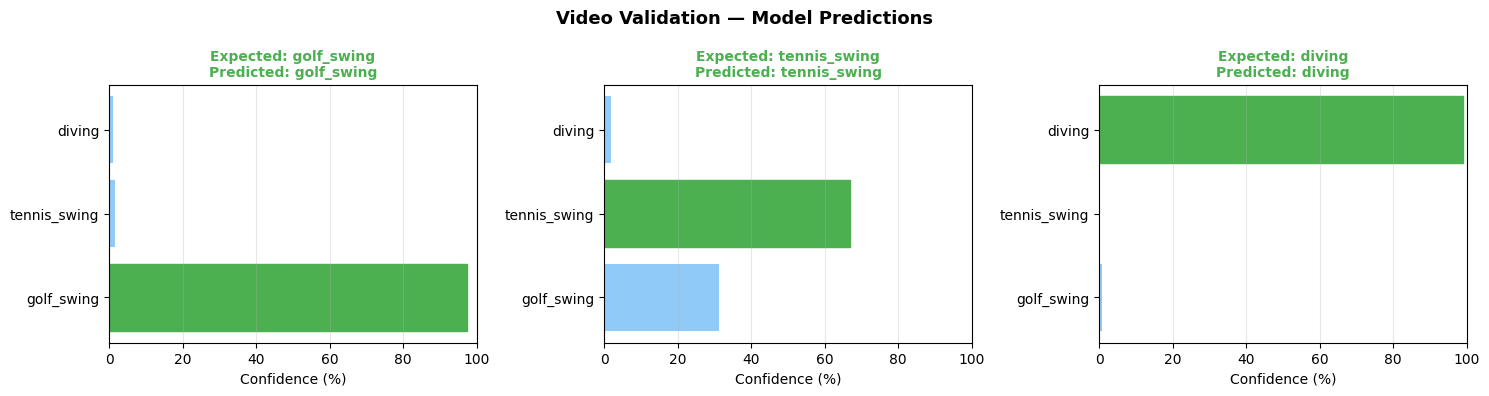


🎯 Validation Accuracy: 3/3 = 100.0%


In [31]:
import matplotlib.pyplot as plt

valid = [r for r in results if r["probs"] is not None]

if valid:
    fig, axes = plt.subplots(1, len(valid), figsize=(5 * len(valid), 4))

    # Fix when only 1 video
    if len(valid) == 1:
        axes = [axes]

    for ax, res in zip(axes, valid):
        probs = res["probs"] * 100  # convert to %

        color = "#4CAF50" if res["expected"] == res["predicted"] else "#F44336"

        bars = ax.barh(CHOSEN_CLASSES, probs, color="#90CAF9")

        # highlight predicted class
        if res["predicted"] in CHOSEN_CLASSES:
            bars[CHOSEN_CLASSES.index(res["predicted"])].set_color(color)

        ax.set_xlim(0, 100)
        ax.set_xlabel("Confidence (%)")

        ax.set_title(
            f"Expected: {res['expected']}\nPredicted: {res['predicted']}",
            color=color,
            fontweight="bold",
            fontsize=10
        )

        ax.grid(axis="x", alpha=0.3)

    fig.suptitle(
        "Video Validation — Model Predictions",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    # Accuracy
    correct = sum(1 for r in valid if r["expected"] == r["predicted"])
    print(f"\n🎯 Validation Accuracy: {correct}/{len(valid)} = {correct/len(valid)*100:.1f}%")

else:
    print("❌ No valid results — make sure videos were uploaded and processed.")